In [2]:
from graphviz import Digraph

def create_neural_network_graph():
    dot = Digraph(comment='Neural Network Architecture')
    dot.attr(rankdir='TB', size='12,16')  # Top to Bottom layout
    
    # 定义节点样式
    dot.attr('node', shape='box', style='filled', fontname='Arial', fontsize='10')

    # Generator
    with dot.subgraph(name='cluster_generator') as c:
        c.attr(label='(a) Generator', style='dashed')
        
        c.node('z', 'z\n1×1×Nz', fillcolor='lightgray')
        c.node('y', 'y\nH×W×1', fillcolor='lightgray')
        c.node('conv1', 'conv(3,1,C)\nH×W×C', fillcolor='lightgreen')
        c.node('leaky1', 'Leaky RELU', fillcolor='lightblue')
        c.node('resblock1', 'Res Block\nno norm.\nH×W×C', fillcolor='orange')
        c.node('down1', 'Down(2)\nH/2×W/2×2C', fillcolor='pink')
        c.node('down2', 'Down(2)\nH/4×W/4×4C', fillcolor='pink')
        c.node('down3', 'Down(2)\nH/8×W/8×8C', fillcolor='pink')
        c.node('resblock2', 'Res Block', fillcolor='orange')
        c.node('up1', 'Up(1)\nno concat.\nH/4×W/4×8C', fillcolor='yellow')
        c.node('up2', 'Up(2)\nH/2×W/2×4C', fillcolor='yellow')
        c.node('up3', 'Up(2)\nno upsample\nH×W×2C', fillcolor='yellow')
        c.node('conv2', 'conv(3,1,1)\nH×W×1', fillcolor='lightgreen')
        c.node('sigmoid', 'Sigmoid', fillcolor='lightblue')
        c.node('x_prime', 'x\'\nH×W×1', fillcolor='lightgray')

        # Connect nodes
        c.edge('y', 'conv1')
        c.edge('conv1', 'leaky1')
        c.edge('leaky1', 'resblock1')
        c.edge('resblock1', 'down1')
        c.edge('down1', 'down2')
        c.edge('down2', 'down3')
        c.edge('down3', 'resblock2')
        c.edge('resblock2', 'up1')
        c.edge('up1', 'up2')
        c.edge('up2', 'up3')
        c.edge('up3', 'conv2')
        c.edge('conv2', 'sigmoid')
        c.edge('sigmoid', 'x_prime')

    # Critic
    with dot.subgraph(name='cluster_critic') as c:
        c.attr(label='(b) Critic')
        
        c.node('xy', '(x, y)\nH×W×2', fillcolor='lightgray')
        c.node('cconv1', 'conv(3,1,C)\nH×W×C', fillcolor='lightgreen')
        c.node('cleaky1', 'Leaky RELU', fillcolor='lightblue')
        c.node('cresblock', 'Res Block\nno norm.\nH×W×C', fillcolor='orange')
        c.node('cdown1', 'Down(2)\nH/2×W/2×2C', fillcolor='pink')
        c.node('cdown2', 'Down(2)\nH/4×W/4×4C', fillcolor='pink')
        c.node('cdown3', 'Down(2)\nH/8×W/8×8C', fillcolor='pink')
        c.node('flatten', 'Flatten', fillcolor='purple')
        c.node('dense1', 'Dense(128)', fillcolor='yellow')
        c.node('cleaky2', 'Leaky RELU', fillcolor='lightblue')
        c.node('layernorm', 'Layer norm', fillcolor='purple')
        c.node('dense2', 'Dense(1)', fillcolor='yellow')
        c.node('output', 'Scalar output', fillcolor='lightgray')

        # Connect nodes
        c.edge('xy', 'cconv1')
        c.edge('cconv1', 'cleaky1')
        c.edge('cleaky1', 'cresblock')
        c.edge('cresblock', 'cdown1')
        c.edge('cdown1', 'cdown2')
        c.edge('cdown2', 'cdown3')
        c.edge('cdown3', 'flatten')
        c.edge('flatten', 'dense1')
        c.edge('dense1', 'cleaky2')
        c.edge('cleaky2', 'layernorm')
        c.edge('layernorm', 'dense2')
        c.edge('dense2', 'output')

    # Set node ranks to improve layout
    dot.attr(rank='same')
    dot.edge('z', 'y', style='invis')
    dot.edge('xy', 'y', style='invis')

    return dot

# Generate and save the graph
graph = create_neural_network_graph()
graph.render('neural_network_detailed', format='png', cleanup=True)
print("Graph has been saved as 'neural_network_detailed.png'")

Graph has been saved as 'neural_network_detailed.png'


In [1]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
from PIL import Image, ImageDraw, ImageFont

# 打开你的图片
image_path = './unfixz.png'
img = Image.open(image_path)

# 创建绘图对象
draw = ImageDraw.Draw(img)

# 设置要覆盖原有标题的矩形区域坐标 (根据实际图片调整坐标)
# 假设标题位于图片顶部，可以覆盖顶部的区域
cover_area = [(0, 0), (img.width, 60)]  # 左上角到右上角60像素高的区域
draw.rectangle(cover_area, fill="white") # 用白色填充矩形区域，覆盖原来的标题

# 如果你有自定义字体，可以使用以下方法加载 ttf 字体
font_path = r'C:\Users\BeichenXu\.conda\envs\MasLISA\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSans.ttf'
font = ImageFont.truetype(font_path, 30)

# 添加新标题
new_title = "line chart with unfixed z for 1000 epochs"
text_position = (50, 10)  # 新标题的位置，根据实际需求调整
draw.text((600, 10), new_title, font=font, fill="black")  # 用黑色字体绘制新标题

# 保存修改后的图片
output_path = './new_unfixz.png'
img.save(output_path)

# 显示或者保存图像文件
img.show()  # 或者保存/显示图片

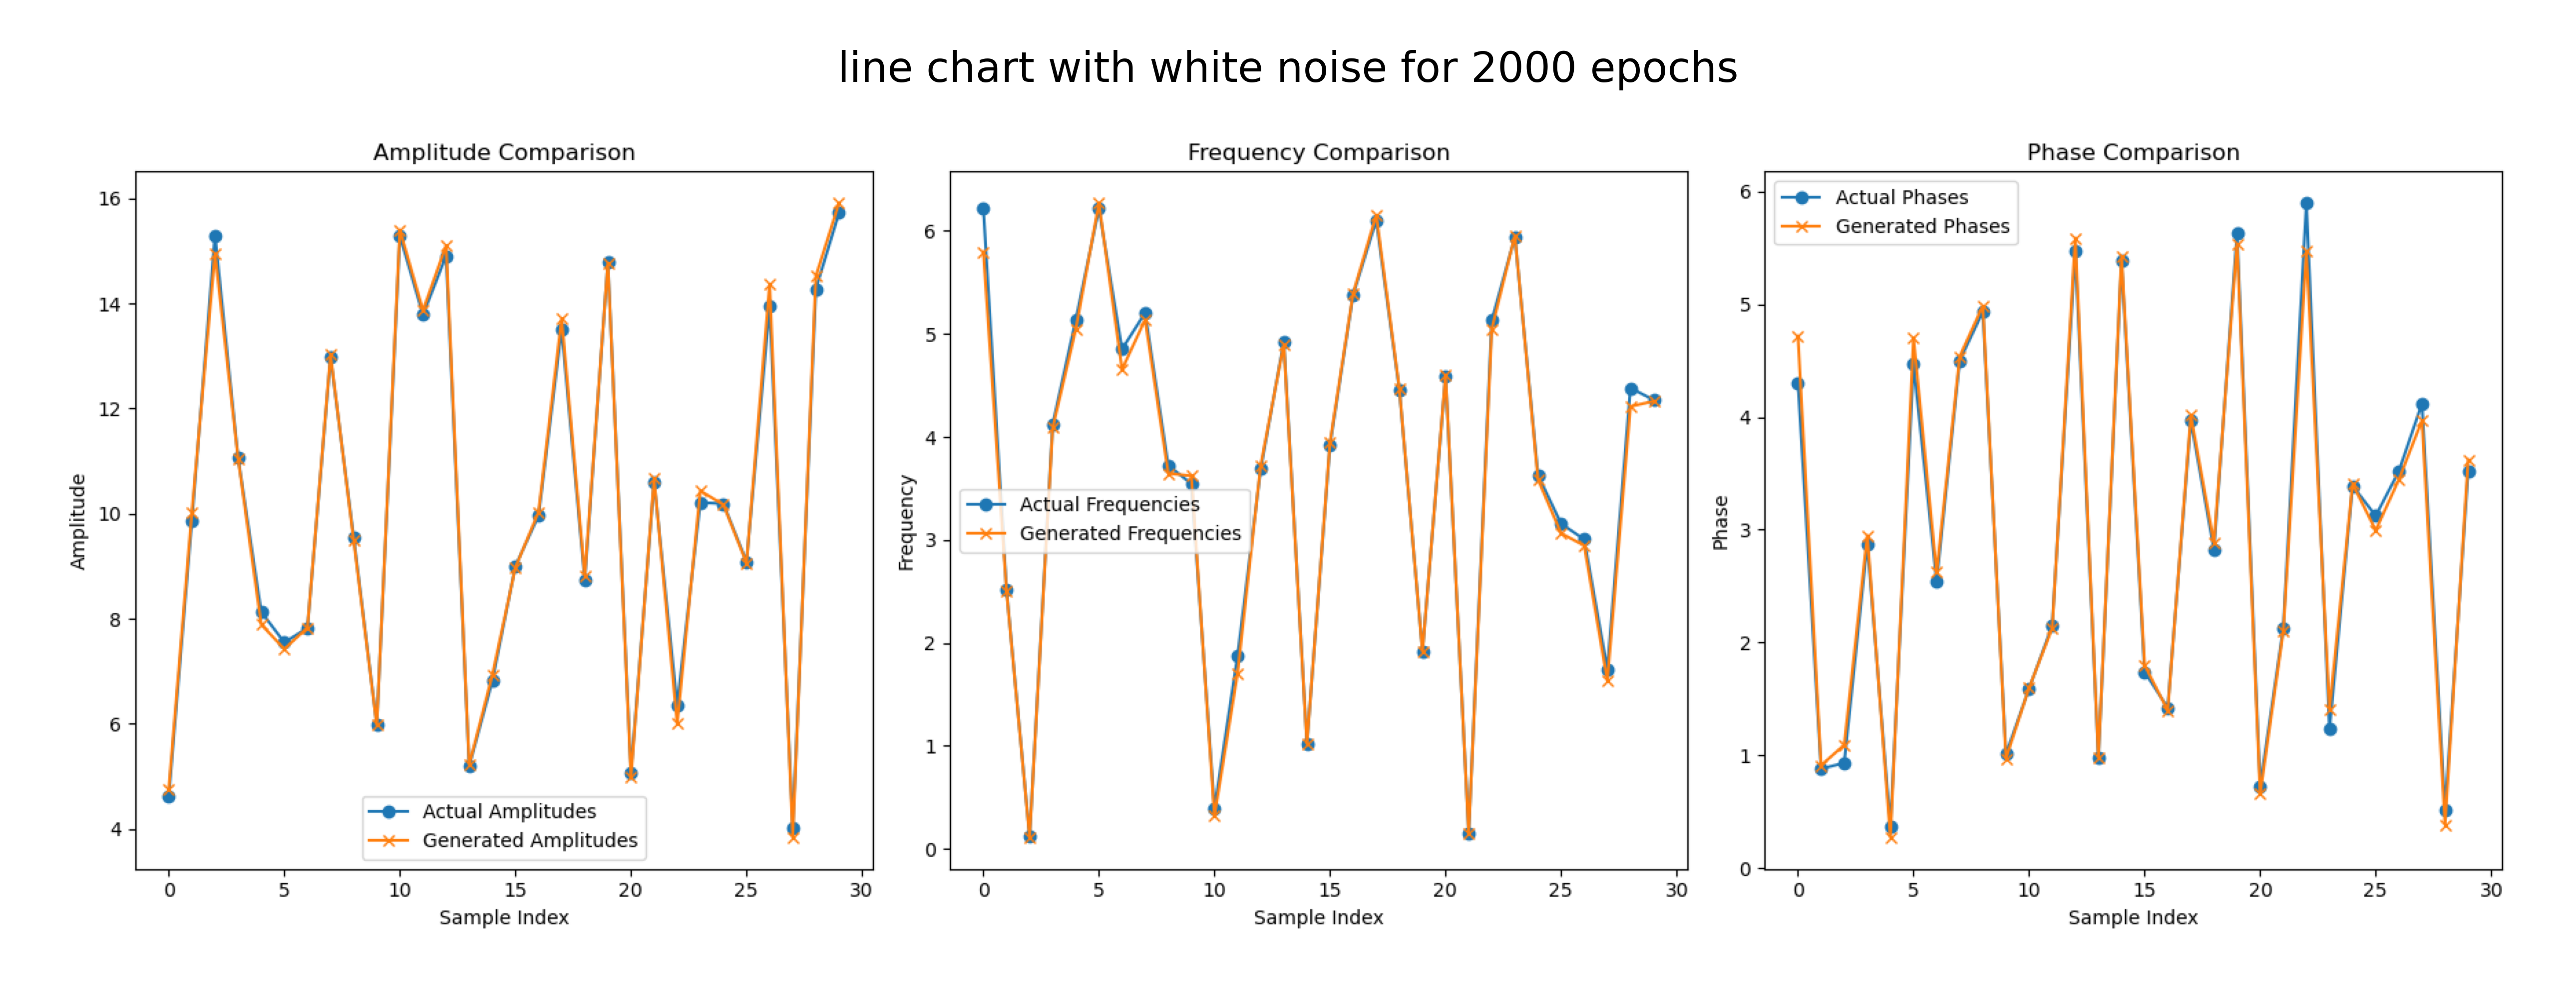

In [33]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 读取图片
img = mpimg.imread('pillow.png')  # 替换为你的图片路径

plt.figure(dpi=1000) 
# 显示图片
plt.imshow(img)

# 添加标题
plt.title("line chart with white noise for 2000 epochs", fontsize=6)

# 隐藏坐标轴
plt.axis('off')

# 显示带标题的图片
plt.show()


In [14]:
import matplotlib.font_manager as fm

# 获取 Matplotlib 默认的字体路径
default_font = fm.findfont(fm.FontProperties(family='DejaVu Sans'))  # 使用 'DejaVu Sans'
print("默认字体路径:", default_font)



默认字体路径: C:\Users\BeichenXu\.conda\envs\MasLISA\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSans.ttf
